<Axes: xlabel='segment'>

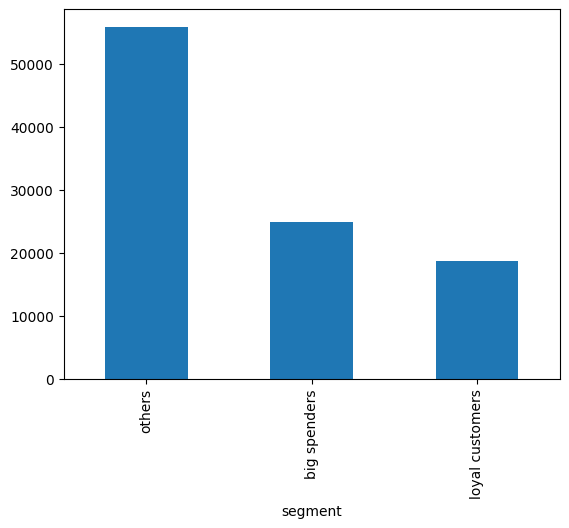

In [7]:
import pandas as pd

df = pd.read_csv('../data/processed/cleaned_data.csv')

df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

# reference date
reference_date = df['order_purchase_timestamp'].max()

# calculate RFM
rfm = df.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (reference_date - x.max()).days,
    'order_id' : 'count',
    'payment_value': 'sum'
}) 

rfm.columns = ['Recency', 'Frequency', 'Monetory']
rfm.head()

rfm.describe()

# create segment
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetory'], 4, labels=[1,2,3,4])

rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm.head()

rfm['segment'] = 'others'

rfm.loc[rfm['RFM_score'] == '444', 'segment'] = 'Best customers'
rfm.loc[rfm['RFM_score'].str.startswith('4'), 'segment'] = 'loyal customers'
rfm.loc[rfm['RFM_score'].str.endswith('4'), 'segment'] = 'big spenders'

rfm['segment'].value_counts()

rfm['segment'].value_counts().plot(kind='bar')


## RFM Analysis Insights

- Customers with high RFM scores are the most valuable customers
- Low recency indicates recent purchases, which is desirable
- High frequency and monetary values indicate loyal and high-spending customers